# Practical Machine Learning                                                                             
# Lab 1

## Exercises

### 1.[Here](https://github.com//practical-ML-fmi/ML/raw/master/Data/lab1/images.zip), we have 8 images, read the images, flatten them, then store them in a numpy array. Before storing the images divide them by 255.
The numpy array should have the dimension equals to (8, 12288), in order to check the dimension use the $shape$ attribute.

In [29]:
import os
import glob
import cv2
import numpy as np

img_dir = "images"
img_paths = sorted(glob.glob(os.path.join(img_dir, "*.*")))

flats = []
for path in img_paths:
    img = cv2.imread(path)              
    if img is None:
        print(f"Failed to load image: {path}")
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    flat = img.flatten() / 255
    flats.append(flat)

images = np.stack(flats)
print("Shape:", images.shape)

Shape: (8, 12288)


### 2. Compute the mean of the images. 

In [30]:
mean_image = np.mean(images, axis=0)
print("Mean image:", mean_image)
print("Mean image shape:", mean_image.shape)

Mean image: [0.27254902 0.34509804 0.22745098 ... 0.37696078 0.40735294 0.33676471]
Mean image shape: (12288,)


### 3. Normalize the images by subtracting the mean from each image.

In [31]:
norm_images = images - mean_image
print("Normalized images:", norm_images)
print("Normalized images shape:", norm_images.shape)

Normalized images: [[-0.20980392 -0.34509804 -0.22352941 ... -0.09460784 -0.19558824
  -0.16813725]
 [-0.09607843 -0.09411765  0.11764706 ...  0.10539216  0.075
   0.16127451]
 [ 0.00196078 -0.04705882 -0.05098039 ...  0.21519608  0.21617647
   0.03578431]
 ...
 [-0.24117647 -0.24313725 -0.19607843 ... -0.36911765 -0.40343137
  -0.325     ]
 [-0.22156863  0.01568627  0.34117647 ...  0.09754902  0.25147059
   0.42009804]
 [ 0.06470588  0.03921569 -0.05098039 ...  0.40343137  0.25147059
   0.20833333]]
Normalized images shape: (8, 12288)


### 4. [Here](https://github.com//practical-ML-fmi/ML/raw/master/Data/lab1/weights.zip), we have the weights and the bias for a perceptron that classifies the images in 4 classes. Use the weights (use np.load(‘path’) to load the weights) and the images (after normalization) to compute (y_hat) the predictions of the perceptron.  
  $$ y_{hat} = softmax(X * W + b) $$
  $$ X - input, W - weights, b - bias $$
  $$Softmax(z_i)=\frac{e^{z_i}}{\sum_{j=1}^{j=K} e^{z_j} }$$

In [32]:
X = norm_images
W = np.load("coefs.npy")
b = np.load("bias.npy")
prob = X @ W + b
y_pred = np.exp(prob) / sum(np.exp(prob))
print("Predicted probabilities:", y_pred)
print("Predicted probabilities shape:", y_pred.shape)

Predicted probabilities: [[4.12220632e-014 2.86596781e-088 1.03731123e-047 2.51102834e-076]
 [1.00000000e+000 4.51286009e-076 1.73665445e-050 2.36816280e-094]
 [1.79820502e-040 9.99999999e-001 7.57816405e-036 2.05981956e-090]
 [6.11039348e-046 1.18144055e-009 5.49200168e-043 2.74920203e-109]
 [5.22896037e-054 1.27064596e-066 2.29927670e-020 8.88768128e-088]
 [2.13970091e-038 1.25221714e-094 1.00000000e+000 1.33014568e-108]
 [5.35208764e-041 5.30972322e-059 2.56499283e-042 1.00000000e+000]
 [2.60160822e-060 2.11868905e-073 1.42513983e-011 3.26464553e-091]]
Predicted probabilities shape: (8, 4)


### 5. Let the ground-truth labels be y = [0, 0, 1, 1, 2,  2, 3,  3]. Compute the accuracy of the classifier (define a new function accuracy_score). 
$$Accuracy = \frac{1}{n} \sum_{i=1}^{j=n} y_{pred}^i == y_{true}^i$$

In [36]:
def accuracy_score(y_true, y_pred):
	correct_predictions = np.sum(y_true == y_pred)
	total_predictions = len(y_true)
	accuracy = correct_predictions / total_predictions
	return accuracy

y_true = np.array([0, 0, 1, 1, 2, 2, 3, 3])
y_pred_classes = np.argmax(y_pred, axis=1)
acc = accuracy_score(y_true, y_pred_classes)
print("Accuracy:", acc)

Accuracy: 0.875


### 6. The labels of the classes are: (Cat - 0,  Dog - 1, Frog - 2,  Horse - 3), print the label for each prediction (use a dictionary). 


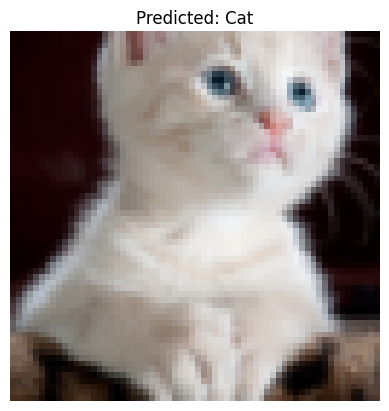

(64, 64, 3)


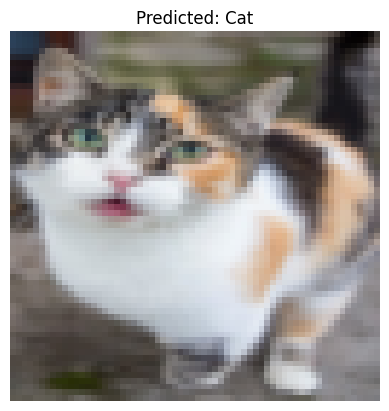

(64, 64, 3)


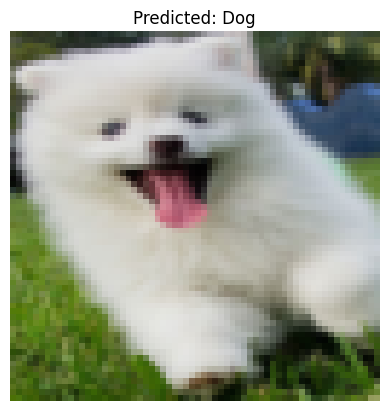

(64, 64, 3)


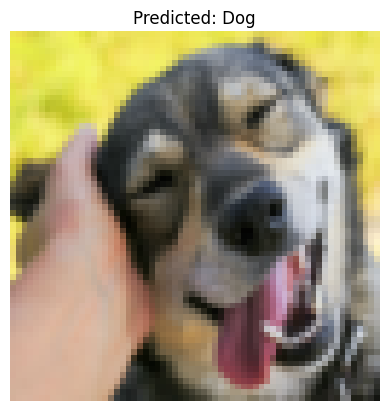

(64, 64, 3)


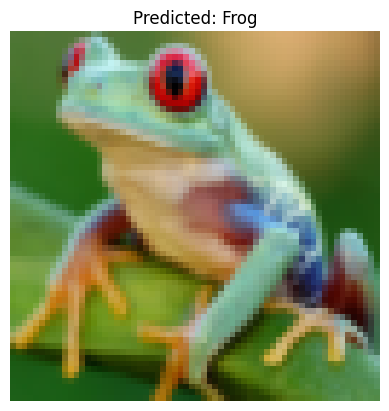

(64, 64, 3)


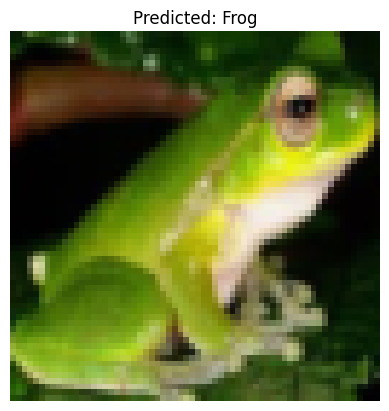

(64, 64, 3)


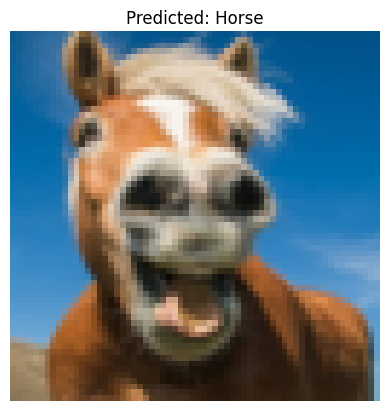

(64, 64, 3)


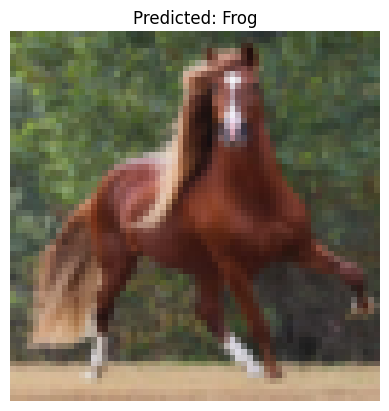

(64, 64, 3)


In [34]:
import matplotlib.pyplot as plt

classes_dict = {0: 'Cat', 1: 'Dog', 2: 'Frog', 3: 'Horse'}
for i, path in enumerate(img_paths):
	img = cv2.imread(path)              
	if img is None:
		print(f"Failed to load image: {path}")
		continue
	img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
	pred_class = y_pred_classes[i]
	plt.imshow(img)
	plt.title(f"Predicted: {classes_dict[pred_class]}")
	plt.axis('off')
	plt.show()
	print(img.shape)

### 7. Display the mean image (use imshow from Matplotlib).
#### Don’t forget to multiply the image by 255, then convert the image to uint8.

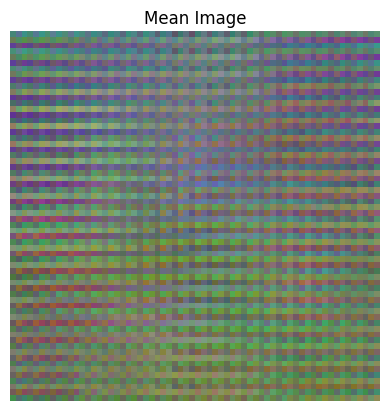

In [28]:
mean_image = (mean_image * 255).astype(np.uint8).reshape(64, 64, 3)
plt.imshow(mean_image)
plt.title("Mean Image")
plt.axis('off')
plt.show()